In [1]:
import os
import math
import json

# using async memory allocator to avoid some cuda allocation errors
# see: https://docs.nvidia.com/deeplearning/frameworks/tensorflow-user-guide/index.html
os.environ['for']='cuda_malloc_async'
# and turning off debugging info
os.environ['TF_CPP_MIN_LOG_LEVEL']='3'

# the "noqa: E402" comments below are to stop the linter picking these up as not being at top of file
# this has been done as the above env. variables need to be set before we import tensorflow
import tensorflow as tf  # noqa: E402
import keras_tuner as kt  # noqa: E402

from datastore import load_datasets,save_hp_search,load_hp_searches  # noqa: E402
from helper_functions import display_samples,eval_model,show_incorrect_predictions  # noqa: E402
from model_constructor import CustomHyperModel  # noqa: E402

# some magic functions
%matplotlib inline

# we want to use mixed precision so
tf.keras.mixed_precision.set_global_policy(tf.keras.mixed_precision.Policy('mixed_float16'))

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3090, compute capability 8.6


In [2]:
# first set some initial data up
dataset_path='datasets/130kv2/'
class_map = {0:"Original", 1:"Poisoned"}

# we won't be varying the batch size yet so set this here too
batch_size=32

Generating preview for dataset 'train' located in 'datasets/130kv2/':


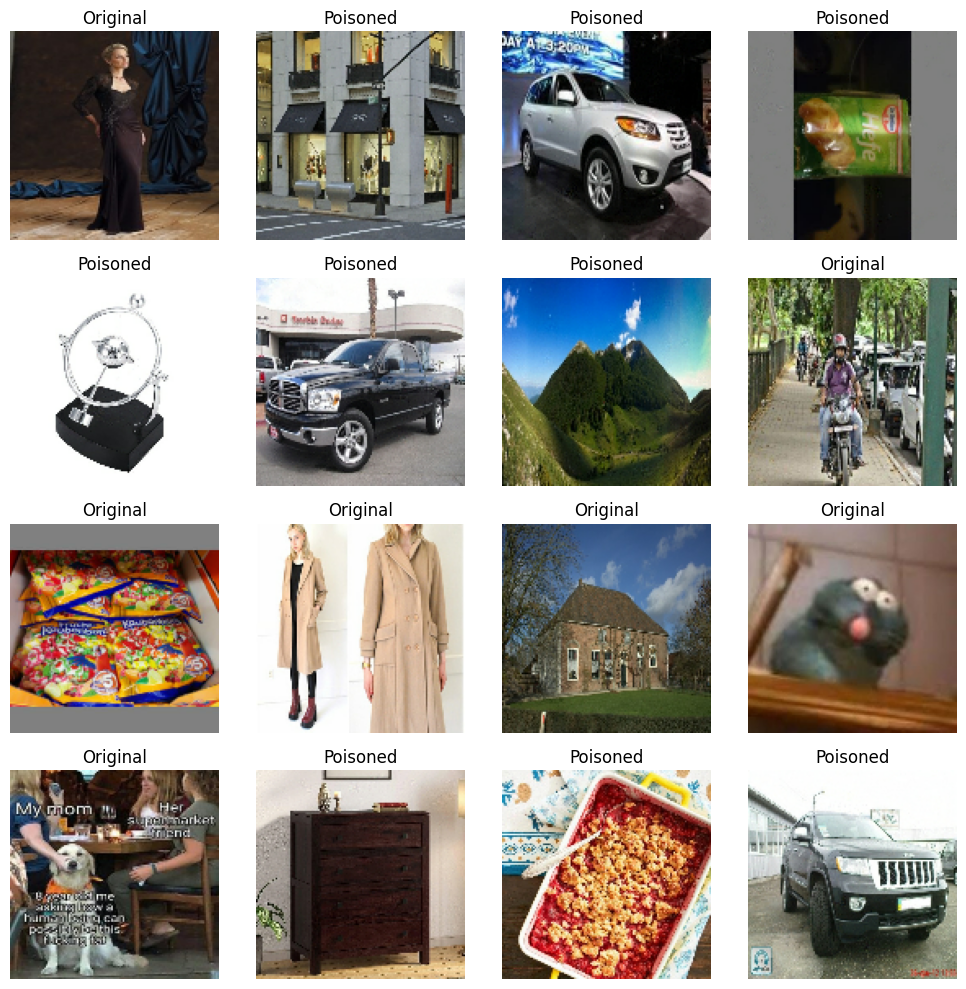

In [3]:
# let's test loading our training, validation and test datasets by generating a preview using resize and a resolution of 256*256
ds = load_datasets(dataset_path, class_map, batch_size, 128, False)

for name, data in ds.items():
    print(f"Generating preview for dataset '{name}' located in '{dataset_path}':")
    display_samples(data.unbatch(),class_map)
    break

In [4]:
# we don't want to have to retype all this for each trial so we need something that can be called for various hp search algorithms, image sizes and resizing methods
def run_trials(search_algo, image_size, crop_and_pad):
    """
    For a given hyperparameter optimisation algorithm, desired image size and resizing method will run a hyperparameter search and save the results to the models\search_results folder.
    
    Results will be stored in csv format with name in format "{search_algo}_size{image_size}_crop{crop_and_pad}.csv".

    Args:
        search_algo (string): which hyperparameter search algorithm to use, either 'bayesopt' or 'hyperband'
        epochs (int): maximum number of epochs to run each trial for
        image_size (int): maximum height/width of the images
        crop_and_pad (bool): whether to crop and pad images, if not they will be resized if height/width of sample differs to image_size
    """
    # load the data first
    ds = load_datasets(dataset_path, class_map, batch_size, image_size, crop_and_pad)
    
    # now create the name for this search, which we'll use to save progress in the autotune folder and serialise the results at the end
    trial_name = f"{search_algo}_size{image_size}_crop{crop_and_pad}"
    
    # lets set up a few tuners
    if search_algo == "bayesopt":
        # we want to set max_epochs on a per-algo basis as we can go a bit higher with hyperband
        max_epochs=15
        tuner = kt.BayesianOptimization(
            hypermodel=CustomHyperModel(input_shape=(image_size,image_size) + (3,), num_classes=2),
            objective='val_accuracy',
            max_trials=30,
            max_model_size=2.5e6, # added this to try and avoid us ending up with oversized models and OOM errors
            # num_initial_points defaults to 3x the dimensionality of the model, that's 36 trials in our case!
            # Anything lower than this would essentially be random search, so we've set it to a somewhat lower value
            num_initial_points=15,
            alpha=1e-3,
            beta=3.,
            #seed=123, # added seed during testing for consistency
            max_retries_per_trial=1, # we'll retry once but these are probably memory errors
            max_consecutive_failed_trials=50,
            directory='autotune',
            project_name=trial_name
        )
    elif search_algo == "hyperband":
        # we'll double max_epochs to 30 here, as it will only go this high on the best performing trials
        max_epochs=30
        tuner = kt.Hyperband(
            CustomHyperModel(input_shape=(image_size,image_size) + (3,), num_classes=2),
            objective='val_accuracy',
            max_epochs=max_epochs,
            max_model_size=2.5e6, # added this to try and avoid us ending up with oversized models and OOM errors
            factor=3,
            hyperband_iterations=1,
            #seed=123, # added seed during testing for consistency
            max_retries_per_trial=1, # we'll retry once but these are probably memory errors
            max_consecutive_failed_trials=50, # skipped trials due to model size count toward this!
            directory='autotune',
            project_name=trial_name
        )

    # set up the callback for early stopping
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5)
    ]

    # and then begin the search
    tuner.search(
        ds['train'],
        epochs=max_epochs,
        callbacks=[callbacks],
        validation_data=ds['validation'],
    )

    # lastly we'll save the top 5 results to file
    save_hp_search(tuner,num_to_save=5,save_folder='results/search_results/')

Before running anything we want to check how long it's going to take and tweak until we're expecting runtime ~24 hours. This likely a pessimistic estimate due to our use of early stopping and skipping over large models.

We have six different searches to run, three with hyperband and three with bayesian optimisation so we calculate how long they'll take approximately with the below then tweak values as required.

In [5]:
# each trial is being run three times so multiply results for both by this figure
num_searches=3

# bayesian optimisation
# https://keras.io/api/keras_tuner/tuners/bayesian/#bayesianoptimization-class
max_epochs=15
max_trials=30
expected_epochs=max_epochs*max_trials*num_searches
runtime_seconds=expected_epochs*45

print(f"Bayesian optimisation will run for a maximum of {expected_epochs} epochs.")
print(f"This is expected to take no more than {runtime_seconds/60/60} hours.")

# hyperband
# see https://keras.io/api/keras_tuner/tuners/hyperband/#hyperband-class
max_epochs=30
factor=3
iterations=1
expected_epochs=max_epochs * (math.log(max_epochs, factor) ** 2) * iterations * num_searches
runtime_seconds=expected_epochs*45

print(f"\nHyperband will run for a maximum of {expected_epochs} epochs.")
print(f"This is expected to take no more than {runtime_seconds/60/60} hours.")

Bayesian optimisation will run for a maximum of 1350 epochs.
This is expected to take no more than 16.875 hours.

Hyperband will run for a maximum of 862.6155375380157 epochs.
This is expected to take no more than 10.782694219225196 hours.


Now we've got a method for running trials, and a reasonable estimate for the time frame, we want to create a combination of searches we can run.

For completeness we want to test:

• bayesopt + hyperband

• sample sizes of either 512x512 or 256x256

• resizing methods of either crop and pad or resize via nearest neighbour

Since the source data is not cropped, padded or resized if the desired image size is the same as the source data we also want to avoid testing both crop and pad and resize for 512x512 images!

In [6]:
# first create tuples of all the possible settings
algos = ('bayesopt','hyperband')
sizes = (512,256)
resize_methods = (True, False)

# now create a list of dicts representing every possible combination
possible_params = [
    {"search_algo":a, "image_size":s, "crop_and_pad":r}
        for a in algos
        for s in sizes
        for r in resize_methods
]

# remove the redundant cases
possible_params = [x for x in possible_params if not (x["image_size"] == 512 and not x["crop_and_pad"])]

# print a few and check the number of entries to check we're on the right path
print(possible_params[:2])
print(len(possible_params))

[{'search_algo': 'bayesopt', 'image_size': 512, 'crop_and_pad': True}, {'search_algo': 'bayesopt', 'image_size': 256, 'crop_and_pad': True}]
6


In [7]:
# now we can run our trials
for params in possible_params:
    run_trials(**params)

Reloading Tuner from autotune/bayesopt_size512_cropTrue/tuner0.json

Top 5 results saved to: results/search_results/bayesopt_size512_cropTrue.csv
Reloading Tuner from autotune/bayesopt_size256_cropTrue/tuner0.json

Top 5 results saved to: results/search_results/bayesopt_size256_cropTrue.csv
Reloading Tuner from autotune/bayesopt_size256_cropFalse/tuner0.json

Top 5 results saved to: results/search_results/bayesopt_size256_cropFalse.csv
Reloading Tuner from autotune/hyperband_size512_cropTrue/tuner0.json

Top 5 results saved to: results/search_results/hyperband_size512_cropTrue.csv
Reloading Tuner from autotune/hyperband_size256_cropTrue/tuner0.json

Top 5 results saved to: results/search_results/hyperband_size256_cropTrue.csv
Reloading Tuner from autotune/hyperband_size256_cropFalse/tuner0.json

Top 5 results saved to: results/search_results/hyperband_size256_cropFalse.csv


Now let's load and take a peek at our results.

In [8]:
results = load_hp_searches(load_folder='results/search_results/',metric='val_accuracy')
for trial in results:
    print(f"{trial['trial']}, {trial['val_accuracy']}")

hyperband_size256_cropTrue, 0.9886363744735718
bayesopt_size512_cropTrue, 0.9848484992980957
bayesopt_size256_cropTrue, 0.9772727489471436
bayesopt_size512_cropTrue, 0.9757575988769531
hyperband_size512_cropTrue, 0.9742424488067627
bayesopt_size512_cropTrue, 0.9727272987365723
hyperband_size256_cropTrue, 0.967424213886261
hyperband_size512_cropTrue, 0.9651514887809753
bayesopt_size256_cropTrue, 0.9628787636756897
bayesopt_size256_cropTrue, 0.9575757384300232
bayesopt_size256_cropTrue, 0.956818163394928
bayesopt_size256_cropTrue, 0.9530302882194519
bayesopt_size512_cropTrue, 0.939393937587738
bayesopt_size256_cropFalse, 0.8787878751754761
hyperband_size512_cropTrue, 0.853787899017334
bayesopt_size512_cropTrue, 0.8515151739120483
hyperband_size512_cropTrue, 0.8484848737716675
hyperband_size256_cropTrue, 0.7681818008422852
hyperband_size512_cropTrue, 0.7515151500701904
bayesopt_size256_cropFalse, 0.543181836605072
hyperband_size256_cropFalse, 0.5181818008422852
bayesopt_size256_cropFalse,

Now we can take the best results and see if we can load a model from the hyperparameters specified within.

In [9]:
def load_from_trial(trial_data):
    # determine the image size and resize method from the filename
    image_size = 512 if '512' in trial_data['trial'] else 256
    crop_and_pad = True if 'cropTrue' in trial_data['trial'] else 256
    # load the dataset
    ds = load_datasets(dataset_path, class_map, batch_size, image_size, crop_and_pad)
    # now filter the trial_data to get what we need and convert the hyperparameters to the correct datatype
    params = {
        'learning_rate': float(trial_data['learning_rate']),
        'normalisation': bool(trial_data['normalisation']),
        'flip_augmentation': bool(trial_data['flip_augmentation']),
        'rotate_augmentation': bool(trial_data['rotate_augmentation']),
        'conv1_size': int(trial_data['conv1_size']),
        'residual_connections': bool(trial_data['residual_connections']),
        'midblock_repetitions': int(trial_data['midblock_repetitions']),
        'midblock_1_size': int(trial_data['midblock_1_size']),
        # some of these may be empty strings, or may not exist, so need to check first
        'midblock_2_size': None if trial_data.get('midblock_2_size','')=='' else int(trial_data.get('midblock_2_size',None)),
        'midblock_3_size': None if trial_data.get('midblock_3_size','')=='' else int(trial_data.get('midblock_3_size',None)),
        'final_conv_size': int(trial_data['final_conv_size']),
        'dropout': float(trial_data['dropout'])
    }
    # print the details of the model before we build it
    print(f"\nLoading model from trial {trial_data['trial']}.")
    print(f"Parameters:\n{params}")
    # lastly we can use CustomHyperModel to build a model for us
    hypermodel = CustomHyperModel(input_shape=(image_size,image_size) + (3,), num_classes=2)
    model = hypermodel.model_builder(**params)
    return ds, model

For the best four results we're going to:
 • create a model with the associated hyperparameters;

 • train the model until it stops improving
 
 • checkpointing the model if its the best seen thus far;

 • reload the best performing checkpoint and evaluate against the validation and test datasets; and
 
 • finally save our training history to a file.

In [10]:
#for i in range(1,5):
#    ds, model = load_from_trial(results[i-1])
#    # reload the model and history (or load if the directory already existed) from checkpoint
#    model = tf.keras.models.load_model(f'results/model{i}/model{i}.keras')
#    show_incorrect_predictions(model, ds['test'], class_map, num_to_display=10)


Loading model from trial hyperband_size256_cropTrue.
Parameters:
{'learning_rate': 0.00016384, 'normalisation': True, 'flip_augmentation': True, 'rotate_augmentation': True, 'conv1_size': 128, 'residual_connections': True, 'midblock_repetitions': 1, 'midblock_1_size': 640, 'midblock_2_size': None, 'midblock_3_size': None, 'final_conv_size': 1024, 'dropout': 0.1}


AttributeError: module 'tensorflow.keras' has no attribute 'ops'


Loading model from trial hyperband_size256_cropTrue.
Parameters:
{'learning_rate': 0.00016384, 'normalisation': True, 'flip_augmentation': True, 'rotate_augmentation': True, 'conv1_size': 128, 'residual_connections': True, 'midblock_repetitions': 1, 'midblock_1_size': 640, 'midblock_2_size': None, 'midblock_3_size': None, 'final_conv_size': 1024, 'dropout': 0.1}

Model1 already exists, proceeding to load model and history from file.


model1 training history


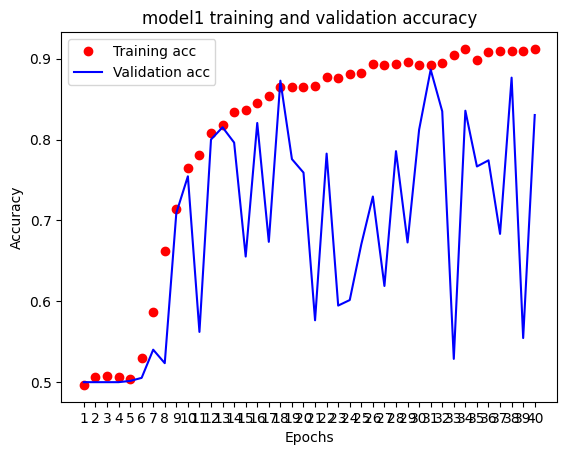

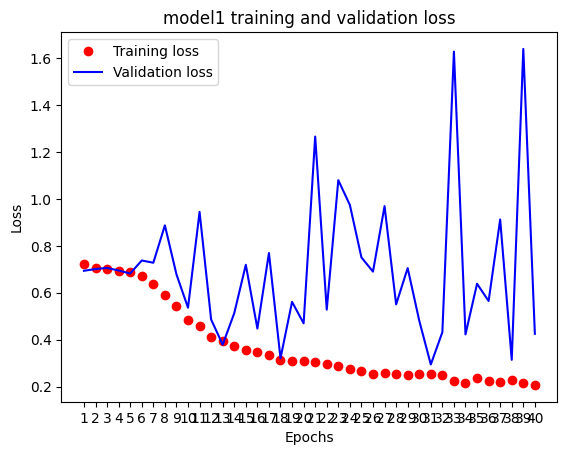


model1 evaluation on validation data
loss: 0.0
tp: 536.0
fp: 26.0
tn: 634.0
fn: 124.0
accuracy: 0.8863636255264282
precision: 0.9537366628646851
recall: 0.8121212124824524
auc: 0.9090713858604431

model1 evaluation on test data
loss: 0.0
tp: 498.0
fp: 22.0
tn: 638.0
fn: 162.0
accuracy: 0.8606060743331909
precision: 0.9576923251152039
recall: 0.7545454502105713
auc: 0.8833091855049133

Loading model from trial bayesopt_size512_cropTrue.
Parameters:
{'learning_rate': 0.00032768, 'normalisation': True, 'flip_augmentation': True, 'rotate_augmentation': True, 'conv1_size': 128, 'residual_connections': True, 'midblock_repetitions': 3, 'midblock_1_size': 384, 'midblock_2_size': 640, 'midblock_3_size': 384, 'final_conv_size': 1536, 'dropout': 0.30000000000000004}

Model2 already exists, proceeding to load model and history from file.


model2 training history


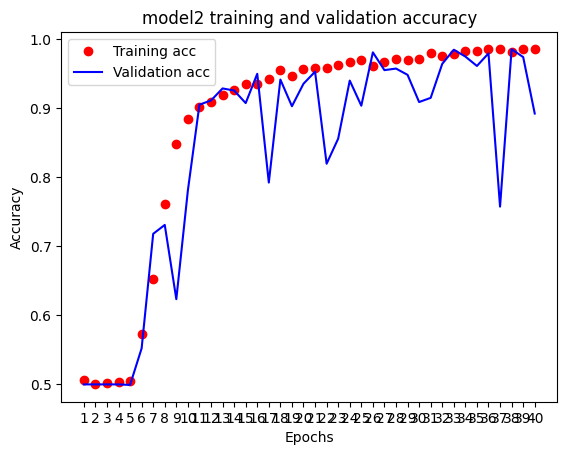

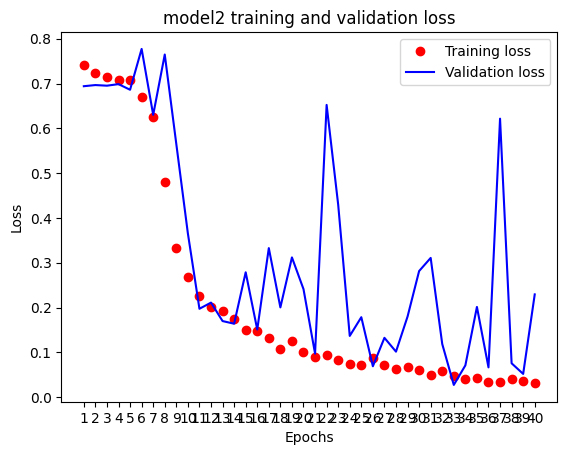


model2 evaluation on validation data
loss: 0.0
tp: 652.0
fp: 11.0
tn: 649.0
fn: 8.0
accuracy: 0.9856060743331909
precision: 0.9834087491035461
recall: 0.9878787994384766
auc: 0.9973714351654053

model2 evaluation on test data
loss: 0.0
tp: 650.0
fp: 12.0
tn: 648.0
fn: 10.0
accuracy: 0.9833333492279053
precision: 0.981873095035553
recall: 0.9848484992980957
auc: 0.9942319989204407

Loading model from trial bayesopt_size256_cropTrue.
Parameters:
{'learning_rate': 0.00032768, 'normalisation': True, 'flip_augmentation': True, 'rotate_augmentation': True, 'conv1_size': 32, 'residual_connections': True, 'midblock_repetitions': 2, 'midblock_1_size': 256, 'midblock_2_size': 384, 'midblock_3_size': None, 'final_conv_size': 896, 'dropout': 0.25}

Model3 already exists, proceeding to load model and history from file.


model3 training history


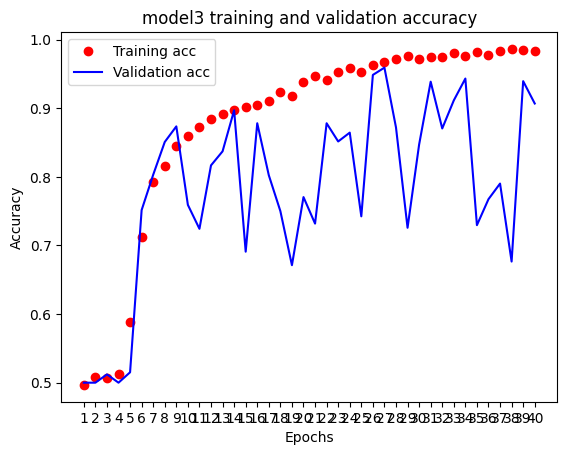

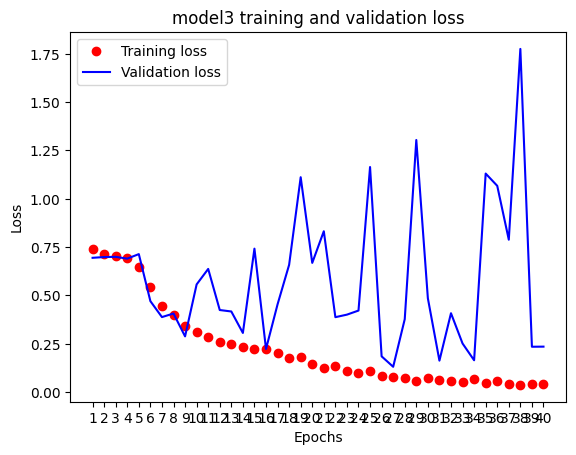


model3 evaluation on validation data


In [ ]:
# first create a dict to store our results in
training_results = {}

for i in range(1,5):
    # load the dataset and create the model
    ds, model = load_from_trial(results[i-1])
    if not (os.path.exists(f'results/model{i}/model{i}.keras') and os.path.exists(f'results/model{i}/model{i}_history.json')):
        # this time we're not going to stop early, we'll train each model to 40 epochs and save the best checkpoint
        callbacks = [
            tf.keras.callbacks.ModelCheckpoint(
                f'results/model{i}/model{i}.keras',
                monitor='val_accuracy',
                mode='max',
                save_best_only=True
            )
        ]
        # train the model and save the history, we'll set the max epochs such that early stopping should kick in
        history = model.fit(
            ds['train'],
            epochs=40,
            verbose=0,
            callbacks=callbacks,
            validation_data=ds['validation'],
        ).history
        #now save the history
        json.dump(history, open(f'results/model{i}/model{i}_history.json', 'w'))
    else:
        print(f'\nModel{i} already exists, proceeding to load model and history from file.\n')
    # reload the model and history (or load if the directory already existed) from checkpoint
    model = tf.keras.models.load_model(f'results/model{i}/model{i}.keras')
    history = json.load(open(f'results/model{i}/model{i}_history.json', 'r'))
    # save a visualisation of the model for use in our report
    tf.keras.utils.plot_model(model,show_shapes=True,to_file=f'results/model{i}/model{i}.png')
    # print the history and evaluate the model
    evaluation = eval_model(f'model{i}',model,history,ds['validation'],ds['test'])
    # put the evaluation results into the dict we created earlier
    training_results.update({f'model{i}':evaluation})

# save all of the results for review in external program(s)
json.dump(training_results, open('results/training_results.json', 'w'))

In [ ]:
for i in range(1,5):
    ds, model = load_from_trial(results[i-1])
    # reload the model and history (or load if the directory already existed) from checkpoint
    model = tf.keras.models.load_model(f'results/model{i}/model{i}.keras')
    show_incorrect_predictions(model, ds['test'], class_map, num_to_display=10)